## About {-}
Harmonic analysis is a type of Fourier analysis that decomposes a signal into its periodic components. Tidal analysis identifies variability in oceanographic time series due to tides. 

I will apply tidal analysis one year of Acoustic Doppler Current Profiler (ADCP) data from the Fisheries and Oceans Canada HAK1 station. The HAK1 mooring station is located off the coast of BC in about 140 m of water and was occupied between 2016 and 2022. The mooring line typically had two Acoustic Doppler Current Profilers (ADCPs) at around 30m and 130 m depth and was replaced once per year in summer. In the map below, the green circle indicates the position of this station.

In [18]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import glob
import pandas as pd
from scipy.interpolate import interpn, griddata
from matplotlib.colors import LogNorm
import matplotlib
from IPython.display import Image, display

sys.path.append(os.path.abspath(
    "/home/hana/Documents/dalhousie/training/CREATE/Data_Module/codes/FFT-analysis"
))
from tidal_plots import *

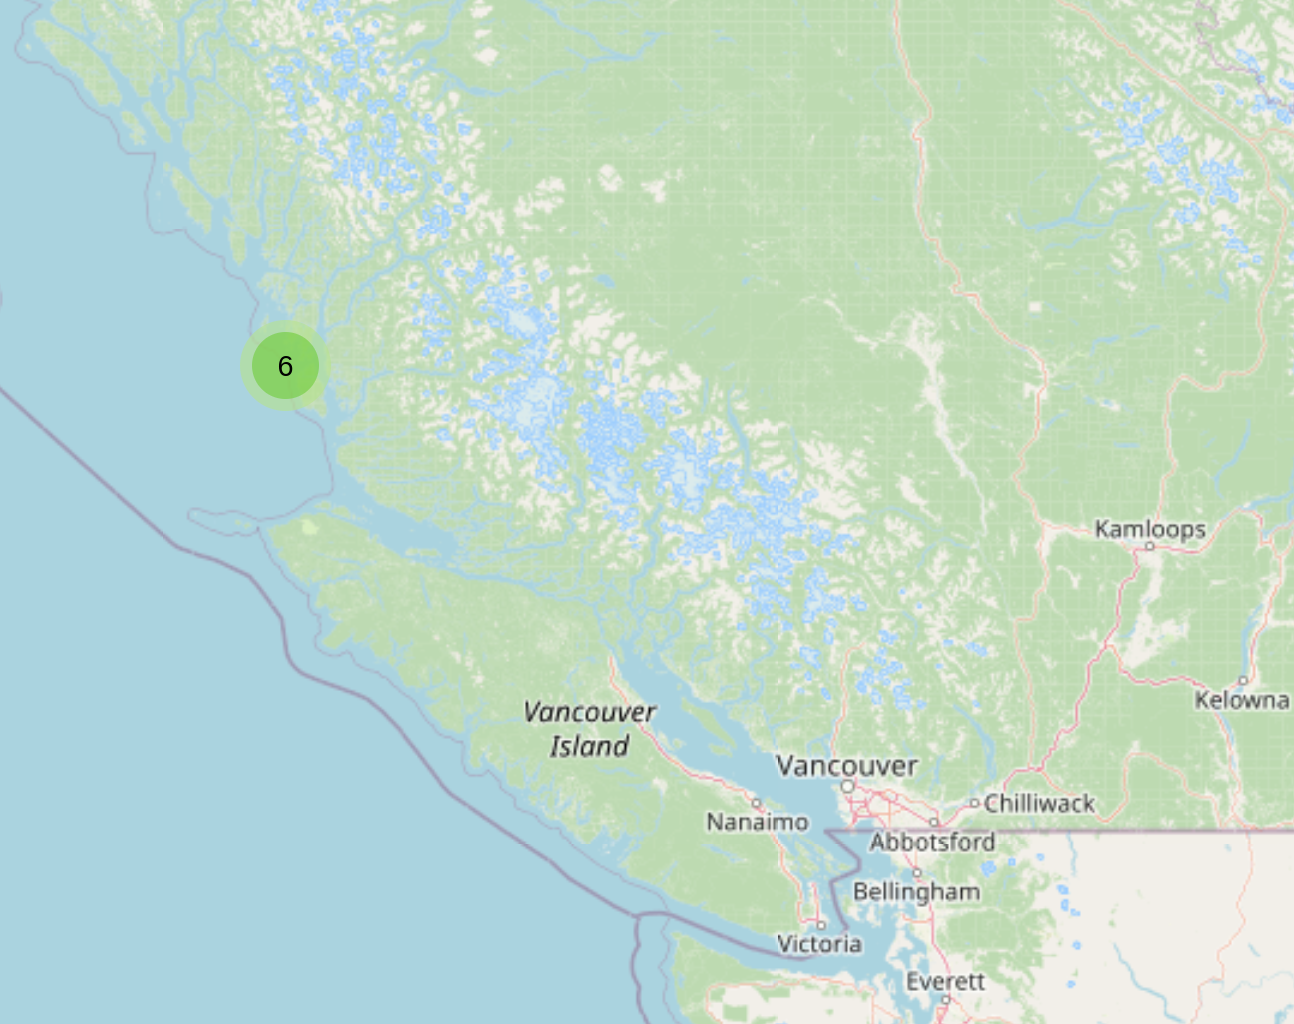

In [19]:
display(Image(
    filename='/home/hana/Documents/dalhousie/training/CREATE/Data_Module/codes/eof-analysis/hak1_mooring_map_wp.png', 
    width=500
))

## Initial plotting {-}

In [20]:
# Import data
haklist = glob.glob('/home/hana/Documents/dalhousie/training/CREATE/Data_Module/data/hak1*.nc')
haklist.sort()

In [21]:
print(haklist[-1])
dat = xr.load_dataset(haklist[-1])

/home/hana/Documents/dalhousie/training/CREATE/Data_Module/data/hak1_20210604_20220718_0132m_L1.adcp.nc


In [22]:
# Bin depth from bin distance from sensor
bin_depths = dat.instrument_depth.data - dat.distance.data

# Mask out data above surface
mask = bin_depths > 0

dat_lim = dat.sel(distance=dat.distance.data[mask])
bins_lim = bin_depths[mask]

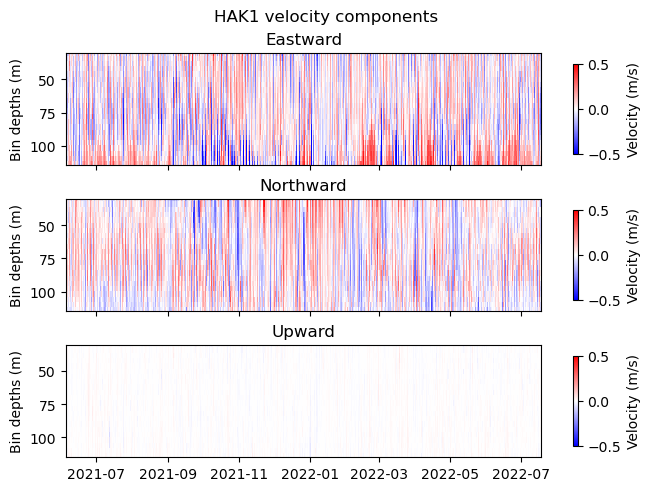

In [35]:
# Make plot
vnames = {
    'LCEWAP01': 'Eastward', 'LCNSAP01': 'Northward', 'LRZAAP01': 'Upward'
}

vlim = 0.5  # color bar limit

fig, axs = plt.subplots(
    nrows=3, sharex=True, sharey=True, layout='constrained'
)

for ii, v in enumerate(vnames.keys()):
    cv = axs[ii].pcolormesh(
        dat_lim.time.data, bins_lim, dat_lim[v].data,
        cmap='bwr', shading='nearest',
        vmin=-vlim, vmax=vlim
    )
    plt.colorbar(cv, label='Velocity (m/s)', shrink=0.8)

    axs[ii].set_ylim(115, 30)
    axs[ii].set_ylabel('Bin depths (m)')
    axs[ii].set_title(vnames[v])

plt.suptitle('HAK1 velocity components')
plt.show()

The eastward velocity component appears stronger at the bottom than at the surface, while the northward velocity component is stronger at the surface than at the bottom. The upward velocity is weakest, which is typical in the ocean.

## Mean velocities and principal component {-}
Time-mean velocities and the principal current direction will be computed.

In [24]:
vel_mean = {k: None for k in vnames.keys()}

for k in vel_mean.keys():
    vel_mean[k] = np.nanmean(dat_lim[k].data, axis=1)

In [25]:
# Code in this section adapted from
# https://github.com/IOS-OSD-DPG/pycurrents_ADCP_processing/blob/master/pycurrents_ADCP_processing/plot_westcoast_nc_LX.py

def fmamidir(u, v):
    """
    Computes principal component direction of u and v
    :param u: Eastward velocity in array format
    :param v: Northward velocity in array format
    :returns : major and minor axes
    """
    ub = np.nanmean(u)
    vb = np.nanmean(v)
    uu = np.nanmean(u ** 2)
    vv = np.nanmean(v ** 2)
    uv = np.nanmean(u * v)
    uu = uu - (ub * ub)
    vv = vv - (vb * vb)
    uv = uv - (ub * vb)

    # Solve for the quadratic
    a = 1.0
    b = -(uu + vv)
    c = (uu * vv) - (uv * uv)
    s1 = (-b + np.sqrt((b * b) - (4.0 * a * c)) / (2.0 * a))
    s2 = (-b - np.sqrt((b * b) - (4.0 * a * c)) / (2.0 * a))
    major = s1
    minor = s2
    if minor > major:
        major = s2
        minor = s1

    # Return major and minor axes
    return major, minor


def fpcdir(x, y):
    """
    Obtain the principal component angle of East and North velocity data
    :param x: Eastward velocity data in array format
    :param y: Northward velocity data in array format
    :return: principal orientation angle
    """
    if x.shape != y.shape:
        ValueError('u and v are different sizes!')
    else:
        # Compute major and minor axes
        major, minor = fmamidir(x, y)

        # Compute principal component direction
        u = x
        v = y
        ub = np.nanmean(u)
        vb = np.nanmean(v)
        uu = np.nanmean(u ** 2)
        uv = np.nanmean(u * v)
        uu = uu - (ub * ub)
        uv = uv - (ub * vb)

        e1 = -uv / (uu - major)
        e2 = 1
        rad_deg = 180 / np.pi  # conversion factor
        theta = np.arctan2(e1, e2) * rad_deg
        theta = -theta  # change rotation angle to be CCW from North

        return theta

In [26]:
orientation = np.zeros(len(bins_lim), dtype='float32')
for ibin in range(len(dat_lim['LCEWAP01'].data)):
    orientation[ibin] = fpcdir(
        dat_lim['LCEWAP01'].data[ibin], dat_lim['LCNSAP01'].data[ibin]
    )  # convert to CW direction

    mean_orientation = np.round(np.nanmean(orientation), decimals=1)
    # coordinate for plotting text
    middle_orientation = np.mean([np.nanmin(orientation), np.nanmax(orientation)])
    mean_depth = np.nanmean(bins_lim)  # text plotting coordinate

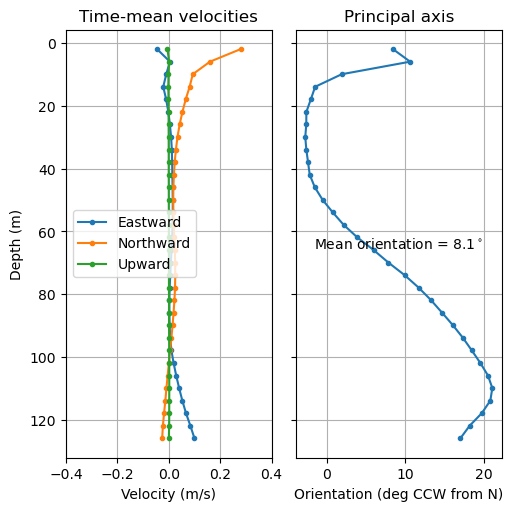

In [27]:
fig, axs = plt.subplots(
    ncols=2, layout='constrained', sharey=True,
    figsize=(5,5)
)

# Time-mean velocities
for k in vel_mean.keys():
    axs[0].plot(
        vel_mean[k], bins_lim, label=vnames[k],
        marker='o', markersize=3
    )

axs[0].grid()  # set grid
axs[0].invert_yaxis()
axs[0].legend(loc='center left')
axs[0].set_xlim(-0.4, 0.4)
axs[0].set_xlabel('Velocity (m/s)')
axs[0].set_ylabel('Depth (m)')
axs[0].set_title('Time-mean velocities')

# Principal component
axs[1].plot(orientation, bins_lim, marker='o', markersize=3)
axs[1].set_xlabel('Orientation (deg CCW from N)')
axs[1].text(
    x=middle_orientation, 
    y=mean_depth,
    s=rf'Mean orientation = {str(mean_orientation)}$^\circ$',
    horizontalalignment='center', 
    verticalalignment='center',
    fontsize=10
)
axs[1].grid()  # set grid
axs[1].set_title('Principal axis')

plt.show()

The principal component is shown in degrees counter-clockwise from North. The mean current direction is NNE.

## Rotary spectra {-}
I will plot the rotary spectra for the current data to determine whether tidal components can be picked out.

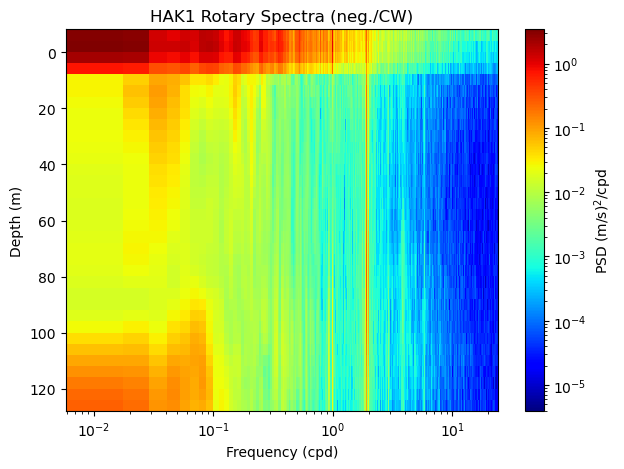

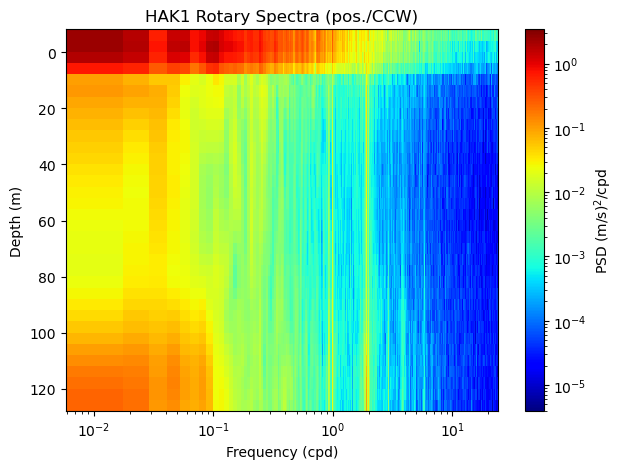

In [29]:
make_depth_prof_rot_spec(
    'HAK1',
    132,
    dat.instrument_depth.data - dat.distance.data,
    dat['LCNSAP01'].data,
    dat['LCEWAP01'].data,
    dat['time'].data
)
# plt.ylim(124, 0)

Rotary spectra are plotted for the negative (clockwise) and positive (counterclockwise) directions. There are bands of higher power spectral density (PSD) at the ~1 and ~2 cycle-per-day frequencies. These might correspond to the luni-solar diurnal K1 (period 23.93 h) and principal lunar M2 (period 12.42 h), respectively. 

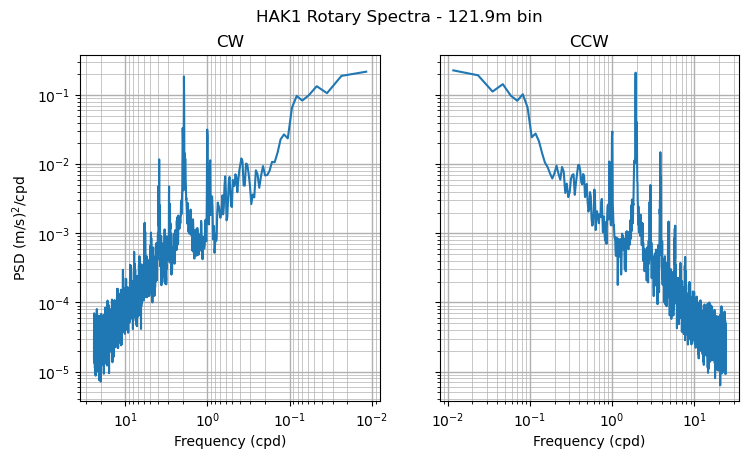

In [30]:
make_plot_rotary_spectra(
    'HAK1',
    132,
    1,
    dat.instrument_depth.data - dat.distance.data,
    dat['time'].data,
    dat['LCNSAP01'].data,
    dat['LCEWAP01'].data,
    dat.latitude.data,
    do_tidal_annotation=False
)

In [34]:
tidal_periods = dict(
    M2 = 12.4206, K1 = 23.9344,
    S2 = 12., O1 = 25.8194,
    N2 = 12.6584, P1 = 24.0659,
    K2 = 11.9673, Q1 = 26.8684
)

for key in tidal_periods.keys():
    # Convert to cycles per day
    print(key, 1/(tidal_periods[key]/24))

M2 1.9322738031979132
K1 1.002740824921452
S2 2.0
O1 0.929533606512932
N2 1.8959742147506795
P1 0.9972616856215643
K2 2.0054648918302376
Q1 0.8932426195828557


Rotary spectra are plotted in a log-log plot for the deepest bin. The largest spikes in power spectral density occur at 1 and 2 cycles per day, which correspond to the M2 and K1 tidal periods. There are some less dominant, faster periodic components at 3 and 4 cycles per day in both directions, and at 5 and 6 cycles per day in the counter-clockwise direction.